## Imports

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
import pandas as pd
from google.colab import files


In [2]:
print("Upload pca.py:")
uploaded = files.upload()
from PCA import NumpyPCA
from gmm import GMM, CovarianceType
from internal_metrics import (silhouette_score, davies_bouldin_index,
                              within_cluster_sum_squares, calinski_harabasz_index)
from external_metrics import adjusted_rand_index, normalized_mutual_information, purity


Upload pca.py:


Saving external_metrics.py to external_metrics.py
Saving gmm.py to gmm.py
Saving internal_metrics.py to internal_metrics.py
Saving PCA.py to PCA.py


## Load the breast cancer dataset

In [3]:

dataset = load_breast_cancer()
X=dataset.data
y=dataset.target

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {dataset.feature_names}")
print(f"\nClass distribution:")
print(f"Class 0 (malignant): {np.sum(y == 0)}")
print(f"Class 1 (benign): {np.sum(y == 1)}")

Dataset Information:
Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Class distribution:
Class 0 (malignant): 212
Class 1 (benign): 357


In [4]:
# Check for missing values
print(f"Missing values: {np.isnan(X).sum()}")  # Should be 0

Missing values: 0


### Standarize the data

In [5]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero for constant features
    std[std == 0] = 1

    X_scaled = (X - mean) / std

    return X_scaled, mean, std

In [6]:
# Standardize
X_scaled, mean, std = standardize(X)

print(f"Original - Mean: {X.mean():.2f}, Std: {X.std():.2f}")
print(f"Scaled   - Mean: {X_scaled.mean():.2f}, Std: {X_scaled.std():.2f}")

Original - Mean: 61.89, Std: 228.30
Scaled   - Mean: -0.00, Std: 1.00


### PCA with Different Dimensions

In [7]:

n_components_pca = [2, 5, 10, 15, 20]
n_components_gmm = range(2, 8)
covariance_types = [CovarianceType.FULL, CovarianceType.TIED,
                    CovarianceType.DIAGONAL, CovarianceType.SPHERICAL]

pca_models = {}
pca_data = {}
pca_metrics = {}

for n_pca in n_components_pca:
    pca = NumpyPCA(n_components=n_pca)
    pca.fit(X_scaled)
    X_pca = pca.transform(X_scaled)

    pca_models[n_pca] = pca
    pca_data[n_pca] = X_pca
    pca_metrics[n_pca] = {
        'reconstruction_error': pca.reconstruction_error(X_scaled),
        'explained_variance': pca.explained_variance_ratio_.sum()
    }


### Train GMM on PCA-Reduced Data

In [9]:
all_results=[]

for n_pca in n_components_pca:
    X_pca = pca_data[n_pca]

    print(f"\n{'='*50}")
    print(f"PCA Dimensions: {n_pca}")
    print(f"{'='*50}")

    for cov_type in covariance_types:
        print(f"\n  Testing {cov_type.value.upper()} covariance:")

        for n_gmm in n_components_gmm:
            # Fit GMM
            gmm = GMM(n_components=n_gmm, cov_type=cov_type,
                     tol=1e-3, max_iter=100, reg_covar=1e-3)
            gmm.fit(X_pca)

            # Predictions
            y_pred = gmm.predict(X_pca)

            # Metrics
            all_results.append({
                'n_pca': n_pca,
                'cov_type': cov_type.value,
                'n_gmm': n_gmm,
                'explained_variance': pca_metrics[n_pca]['explained_variance'],
                'reconstruction_error': pca_metrics[n_pca]['reconstruction_error'],
                'BIC': gmm.bic(X_pca),
                'AIC': gmm.aic(X_pca),
                'Log-Likelihood': gmm.log_likelihoods[-1],
                'Iterations': len(gmm.log_likelihoods),
                'Silhouette': silhouette_score(X_pca, y_pred),
                'Davies-Bouldin': davies_bouldin_index(X_pca, y_pred),
                'Calinski-Harabasz': calinski_harabasz_index(X_pca, y_pred),
                'WCSS': within_cluster_sum_squares(X_pca, y_pred),
                'ARI': adjusted_rand_index(y, y_pred),
                'NMI': normalized_mutual_information(y, y_pred),
                'Purity': purity(y, y_pred)
            })

            print(f"    n_gmm={n_gmm}: BIC={all_results[-1]['BIC']:.2f}, "
                  f"ARI={all_results[-1]['ARI']:.4f}")

df_results = pd.DataFrame(all_results)


PCA Dimensions: 2

  Testing FULL covariance:
Converged at iteration 18
    n_gmm=2: BIC=5414.72, ARI=0.6325
    n_gmm=3: BIC=5415.03, ARI=0.5722
    n_gmm=4: BIC=5441.28, ARI=0.5361
    n_gmm=5: BIC=5477.06, ARI=0.3662
    n_gmm=6: BIC=5503.34, ARI=0.2504
    n_gmm=7: BIC=5540.34, ARI=0.2177

  Testing TIED covariance:
Converged at iteration 47
    n_gmm=2: BIC=5741.41, ARI=0.0764
Converged at iteration 40
    n_gmm=3: BIC=5657.70, ARI=0.5342
Converged at iteration 57
    n_gmm=4: BIC=5656.47, ARI=0.4253
Converged at iteration 48
    n_gmm=5: BIC=5600.08, ARI=0.5241
Converged at iteration 31
    n_gmm=6: BIC=5612.11, ARI=0.5342
Converged at iteration 96
    n_gmm=7: BIC=5606.68, ARI=0.5046

  Testing DIAG covariance:
Converged at iteration 20
    n_gmm=2: BIC=5417.28, ARI=0.6213
    n_gmm=3: BIC=5419.34, ARI=0.6252
    n_gmm=4: BIC=5442.45, ARI=0.3504
    n_gmm=5: BIC=5442.83, ARI=0.3241
    n_gmm=6: BIC=5473.78, ARI=0.2176
    n_gmm=7: BIC=5498.88, ARI=0.2663

  Testing SPHERICAL co

### Find Optimal Configuration for Each PCA Dimension

In [11]:
optimal_configs = []

for n_pca in n_components_pca:
    df_pca = df_results[df_results['n_pca'] == n_pca]
    best_bic = df_pca.loc[df_pca['BIC'].idxmin()]
    optimal_configs.append(best_bic)

    print(f"\nPCA {n_pca} components:")
    print(f"  Best: {best_bic['cov_type']}, n_gmm={best_bic['n_gmm']:.0f}")
    print(f"  BIC: {best_bic['BIC']:.2f}, ARI: {best_bic['ARI']:.4f}")

# Overall best configuration
overall_best = df_results.loc[df_results['BIC'].idxmin()]
print(f"\nOverall Best: PCA={overall_best['n_pca']}, "
      f"{overall_best['cov_type'].upper()}, n_gmm={overall_best['n_gmm']:.0f}")


PCA 2 components:
  Best: spherical, n_gmm=2
  BIC: 5407.88, ARI: 0.6156

PCA 5 components:
  Best: full, n_gmm=4
  BIC: 11142.10, ARI: 0.4373

PCA 10 components:
  Best: diag, n_gmm=5
  BIC: 17140.09, ARI: 0.3712

PCA 15 components:
  Best: diag, n_gmm=4
  BIC: 19979.99, ARI: 0.2914

PCA 20 components:
  Best: diag, n_gmm=4
  BIC: 18834.94, ARI: 0.3507

Overall Best: PCA=2, SPHERICAL, n_gmm=2


### Visualizations

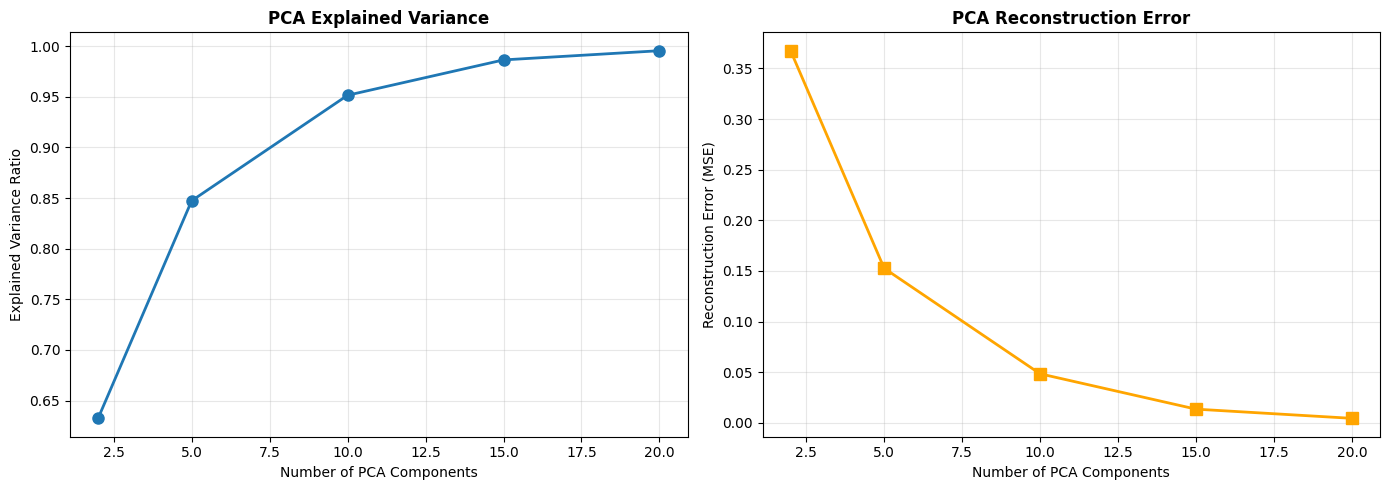

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Explained variance
pca_dims = list(pca_metrics.keys())
explained_vars = [pca_metrics[n]['explained_variance'] for n in pca_dims]
ax1.plot(pca_dims, explained_vars, marker='o', linewidth=2, markersize=8)
ax1.set_xlabel('Number of PCA Components')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('PCA Explained Variance', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Reconstruction error
recon_errors = [pca_metrics[n]['reconstruction_error'] for n in pca_dims]
ax2.plot(pca_dims, recon_errors, marker='s', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Number of PCA Components')
ax2.set_ylabel('Reconstruction Error (MSE)')
ax2.set_title('PCA Reconstruction Error', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### BIC/AIC Comparison Across PCA Dimensions

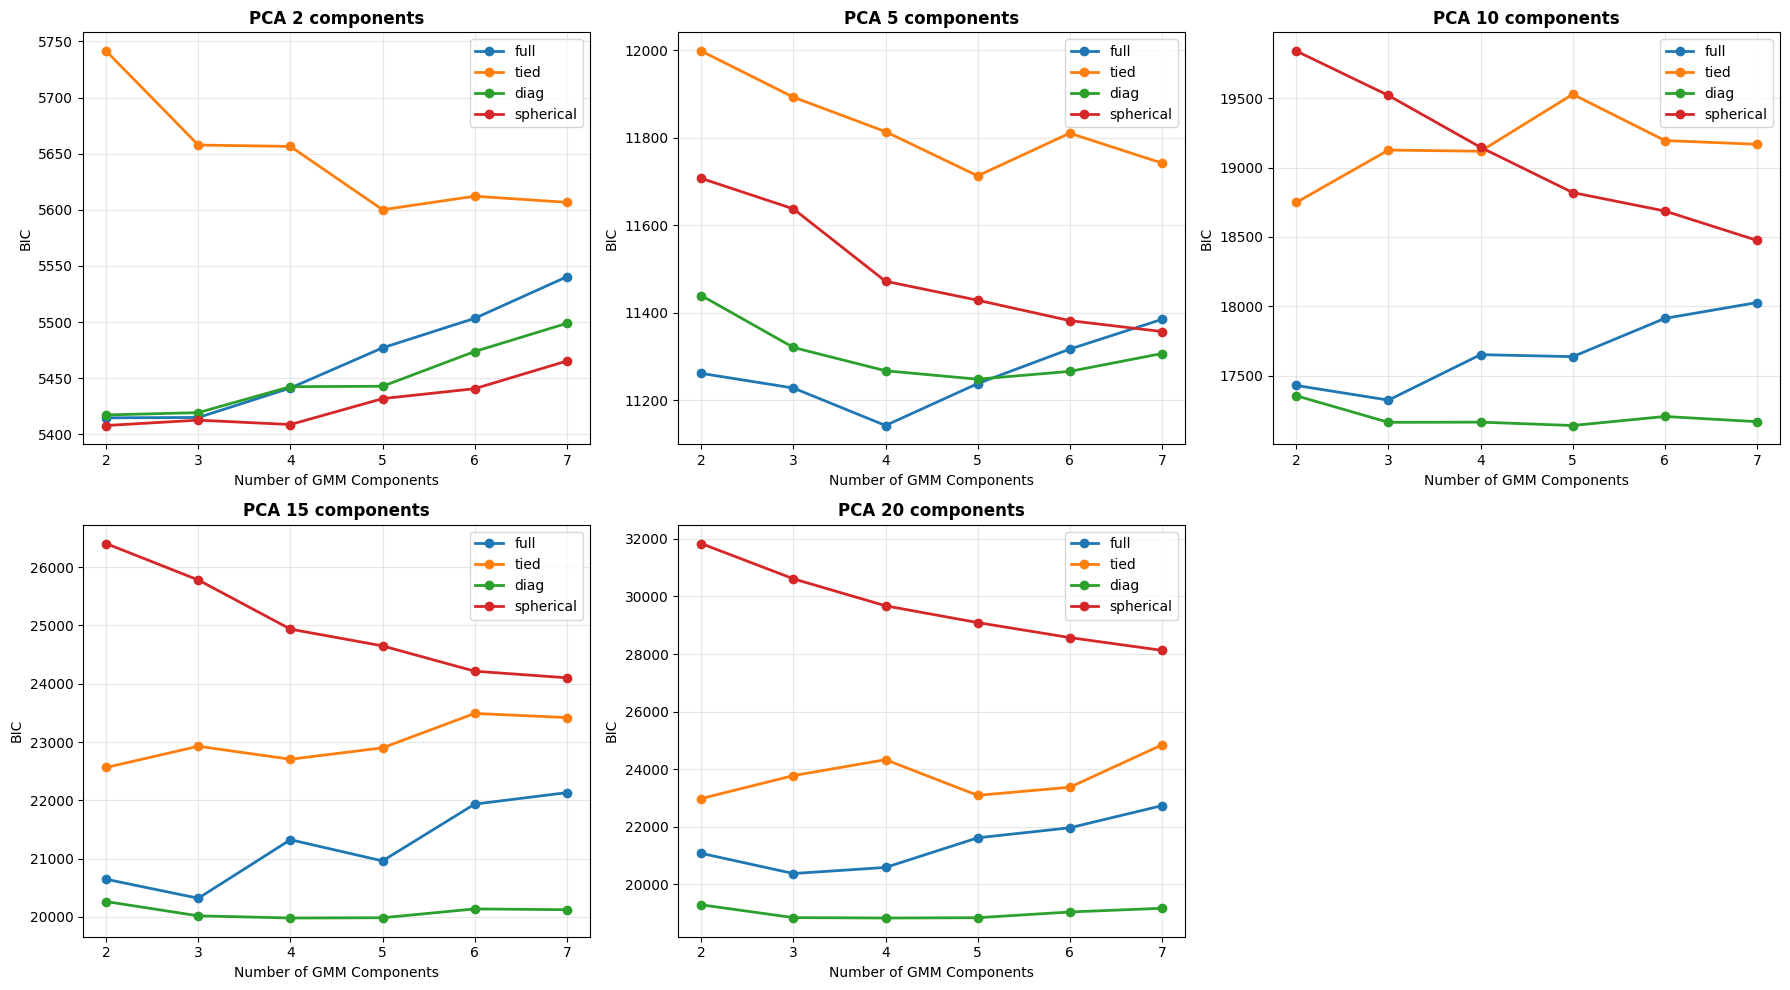

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, n_pca in enumerate(n_components_pca):
    df_pca = df_results[df_results['n_pca'] == n_pca]

    for cov_type in covariance_types:
        data = df_pca[df_pca['cov_type'] == cov_type.value]
        axes[idx].plot(data['n_gmm'], data['BIC'],
                      marker='o', label=cov_type.value, linewidth=2)

    axes[idx].set_xlabel('Number of GMM Components')
    axes[idx].set_ylabel('BIC')
    axes[idx].set_title(f'PCA {n_pca} components', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### Best Covariance Type per PCA Dimension

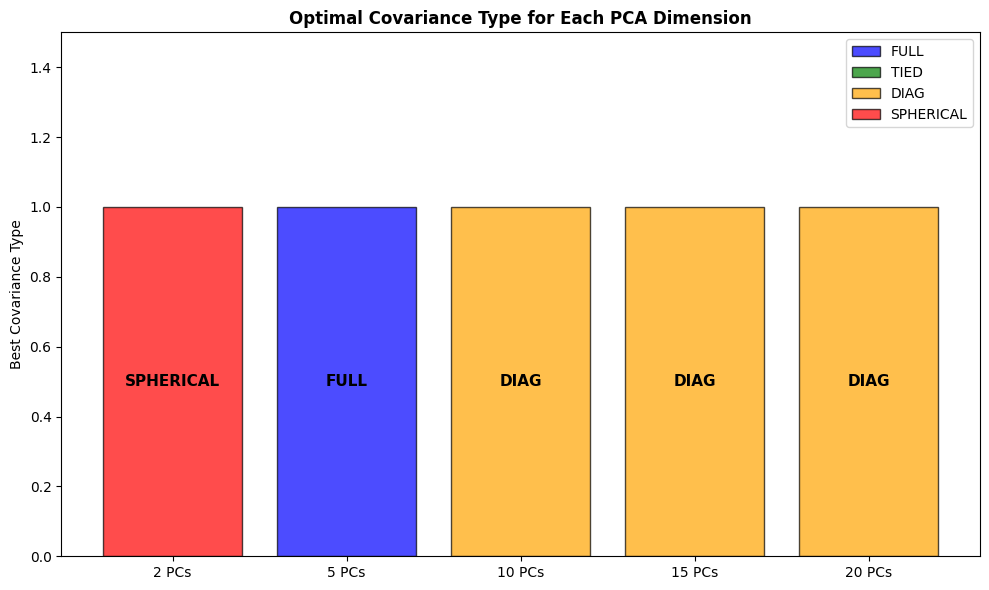


Optimal Covariance Type per PCA Dimension:
  PCA 2: SPHERICAL
  PCA 5: FULL
  PCA 10: DIAG
  PCA 15: DIAG
  PCA 20: DIAG


In [14]:
# Find best covariance type for each PCA dimension
best_cov_per_pca = []
for n_pca in n_components_pca:
    df_pca = df_results[df_results['n_pca'] == n_pca]
    best = df_pca.loc[df_pca['BIC'].idxmin()]
    best_cov_per_pca.append(best['cov_type'])

plt.figure(figsize=(10, 6))
x_pos = np.arange(len(n_components_pca))
colors = {'full': 'blue', 'tied': 'green', 'diag': 'orange', 'spherical': 'red'}
bar_colors = [colors[cov] for cov in best_cov_per_pca]

plt.bar(x_pos, [1]*len(n_components_pca), color=bar_colors, alpha=0.7, edgecolor='black')
plt.xticks(x_pos, [f'{n} PCs' for n in n_components_pca])
plt.ylabel('Best Covariance Type')
plt.title('Optimal Covariance Type for Each PCA Dimension', fontweight='bold')
plt.ylim(0, 1.5)

# Add text labels
for i, cov in enumerate(best_cov_per_pca):
    plt.text(i, 0.5, cov.upper(), ha='center', va='center', fontweight='bold', fontsize=11)

# Legend
legend_elements = [plt.Rectangle((0,0),1,1, fc=colors[k], alpha=0.7, edgecolor='black', label=k.upper())
                   for k in colors.keys()]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print("\nOptimal Covariance Type per PCA Dimension:")
for n_pca, cov in zip(n_components_pca, best_cov_per_pca):
    print(f"  PCA {n_pca}: {cov.upper()}")

### Clustering Performance vs Dimensionality

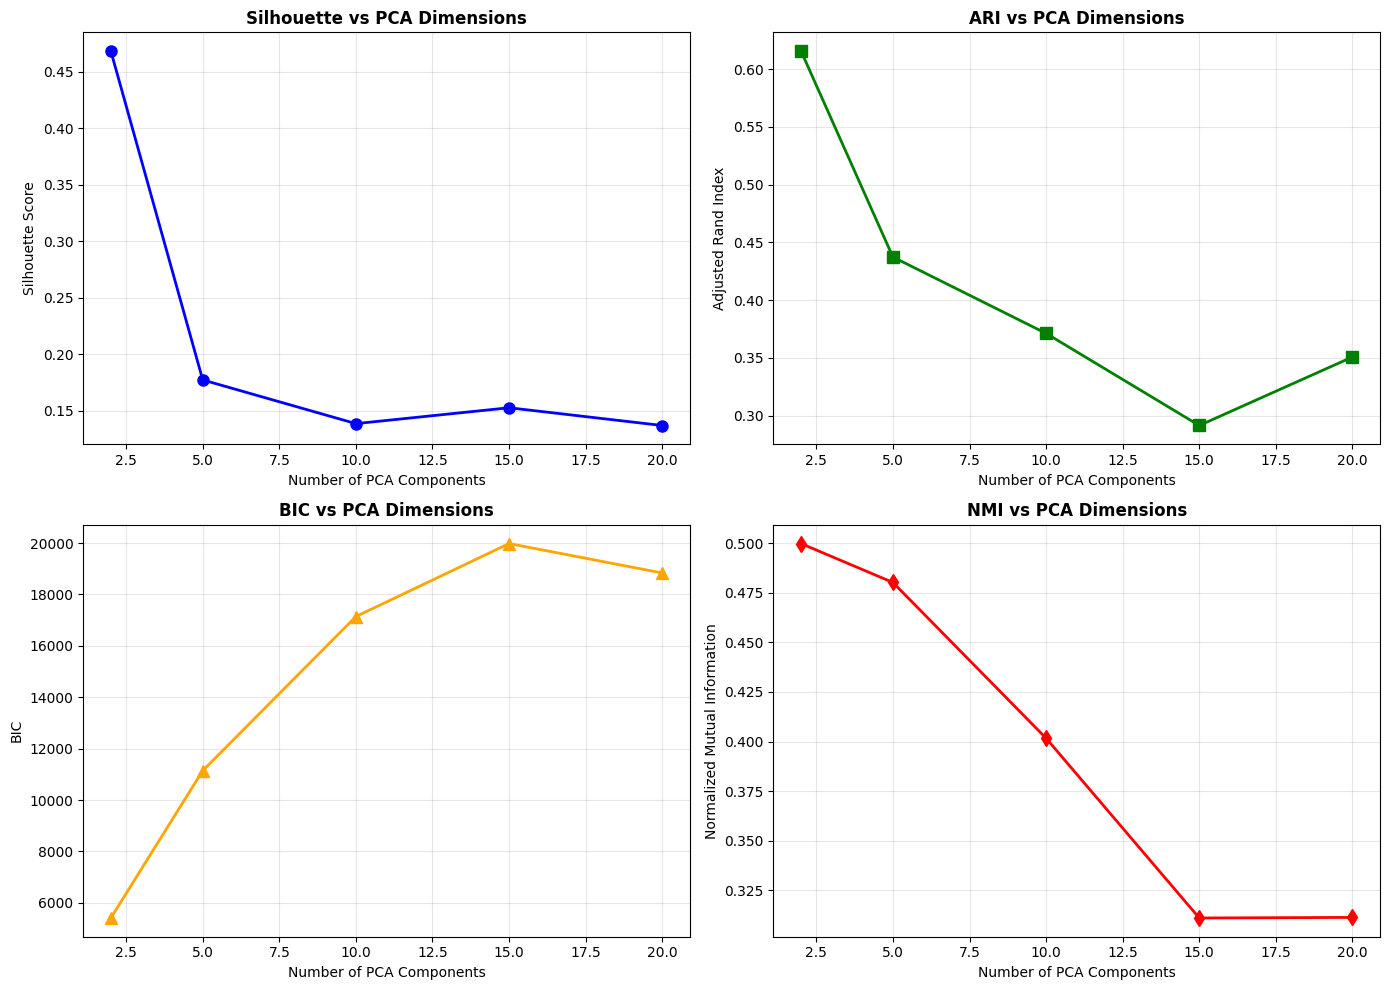

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get best configuration for each PCA dimension
best_per_pca = []
for n_pca in n_components_pca:
    df_pca = df_results[df_results['n_pca'] == n_pca]
    best_per_pca.append(df_pca.loc[df_pca['BIC'].idxmin()])

df_best = pd.DataFrame(best_per_pca)

# Silhouette
axes[0, 0].plot(df_best['n_pca'], df_best['Silhouette'],
               marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Number of PCA Components')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Silhouette vs PCA Dimensions', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# ARI
axes[0, 1].plot(df_best['n_pca'], df_best['ARI'],
               marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Number of PCA Components')
axes[0, 1].set_ylabel('Adjusted Rand Index')
axes[0, 1].set_title('ARI vs PCA Dimensions', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# BIC
axes[1, 0].plot(df_best['n_pca'], df_best['BIC'],
               marker='^', linewidth=2, markersize=8, color='orange')
axes[1, 0].set_xlabel('Number of PCA Components')
axes[1, 0].set_ylabel('BIC')
axes[1, 0].set_title('BIC vs PCA Dimensions', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# NMI
axes[1, 1].plot(df_best['n_pca'], df_best['NMI'],
               marker='d', linewidth=2, markersize=8, color='red')
axes[1, 1].set_xlabel('Number of PCA Components')
axes[1, 1].set_ylabel('Normalized Mutual Information')
axes[1, 1].set_title('NMI vs PCA Dimensions', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###  Reconstruction Error vs Clustering Quality

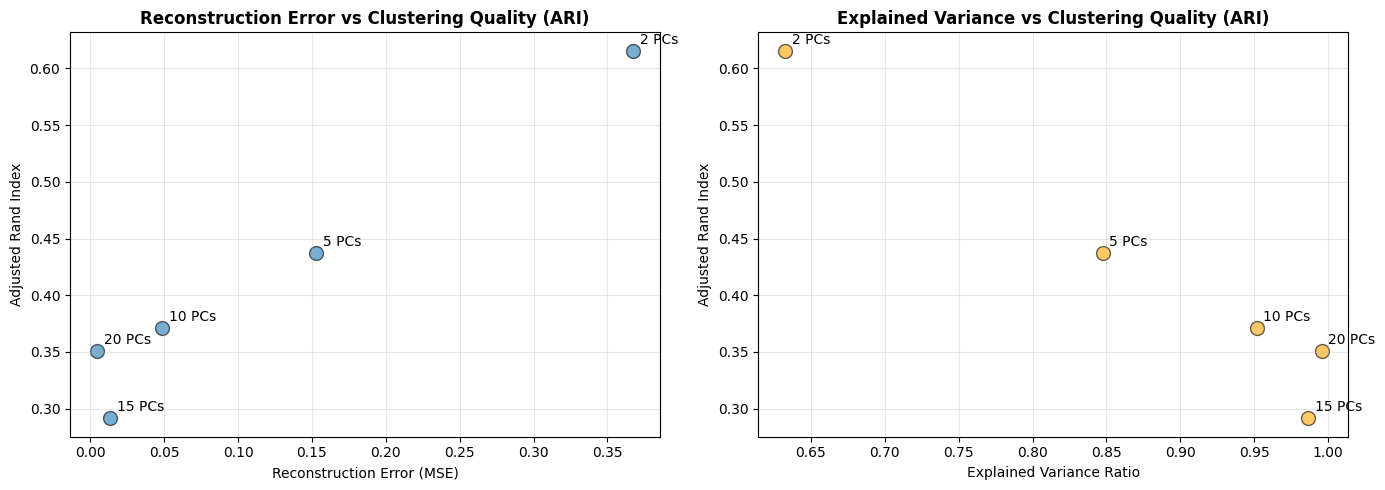

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reconstruction Error vs ARI
axes[0].scatter(df_best['reconstruction_error'], df_best['ARI'],
               s=100, alpha=0.6, edgecolors='k')
for i, n_pca in enumerate(df_best['n_pca']):
    axes[0].annotate(f'{int(n_pca)} PCs',
                    (df_best['reconstruction_error'].iloc[i], df_best['ARI'].iloc[i]),
                    xytext=(5, 5), textcoords='offset points')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Adjusted Rand Index')
axes[0].set_title('Reconstruction Error vs Clustering Quality (ARI)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Explained Variance vs ARI
axes[1].scatter(df_best['explained_variance'], df_best['ARI'],
               s=100, alpha=0.6, edgecolors='k', color='orange')
for i, n_pca in enumerate(df_best['n_pca']):
    axes[1].annotate(f'{int(n_pca)} PCs',
                    (df_best['explained_variance'].iloc[i], df_best['ARI'].iloc[i]),
                    xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Explained Variance Ratio')
axes[1].set_ylabel('Adjusted Rand Index')
axes[1].set_title('Explained Variance vs Clustering Quality (ARI)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization using PCA

Converged at iteration 19


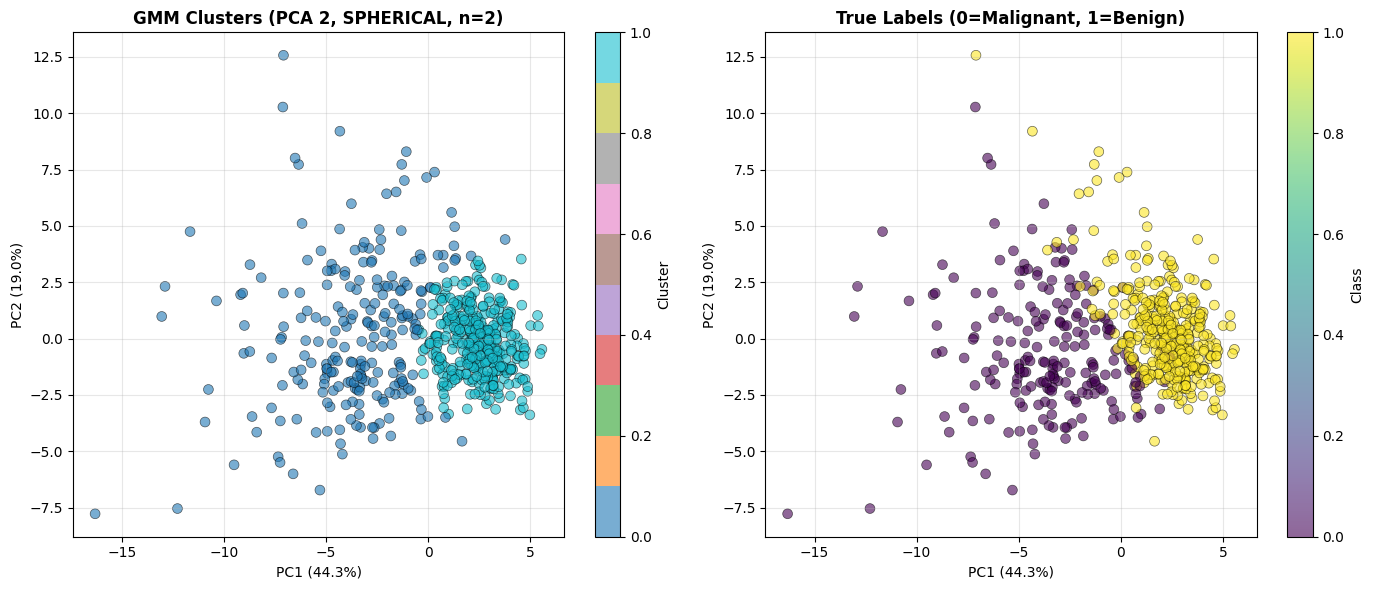

In [17]:
pca_2d = NumpyPCA(n_components=2)
pca_2d.fit(X_scaled)
X_2d = pca_2d.transform(X_scaled)

# Train optimal model on its optimal PCA dimension
optimal_n_pca = int(overall_best['n_pca'])
optimal_cov_type = {'full': CovarianceType.FULL, 'tied': CovarianceType.TIED,
                    'diag': CovarianceType.DIAGONAL, 'spherical': CovarianceType.SPHERICAL}[overall_best['cov_type']]
optimal_n_gmm = int(overall_best['n_gmm'])

X_optimal_pca = pca_data[optimal_n_pca]
optimal_gmm = GMM(n_components=optimal_n_gmm, cov_type=optimal_cov_type,
                  tol=1e-3, max_iter=100, reg_covar=1e-3)
optimal_gmm.fit(X_optimal_pca)
y_pred_optimal = optimal_gmm.predict(X_optimal_pca)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Predicted clusters
scatter1 = ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=y_pred_optimal,
                      cmap='tab10', alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax1.set_title(f'GMM Clusters (PCA {optimal_n_pca}, {overall_best["cov_type"].upper()}, '
             f'n={optimal_n_gmm})', fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster')
ax1.grid(True, alpha=0.3)

# True labels
scatter2 = ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=y,
                      cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
ax2.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax2.set_title('True Labels (0=Malignant, 1=Benign)', fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Class')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Confusion Matrix

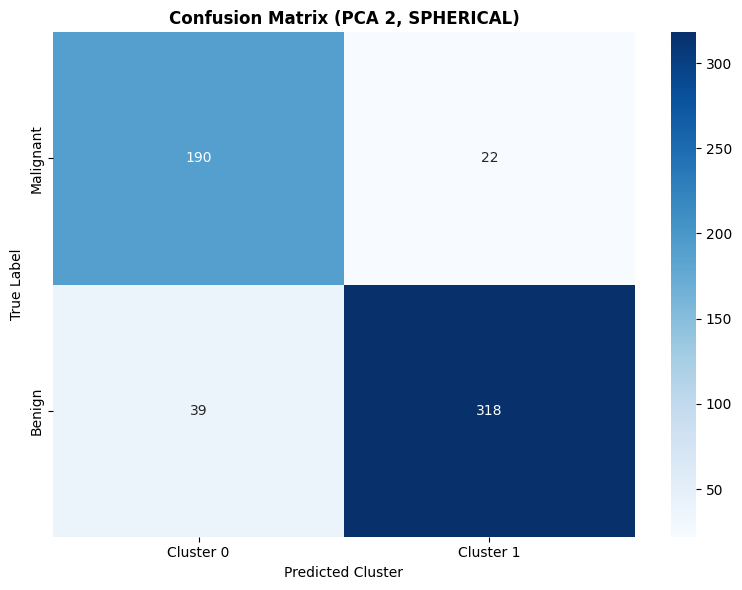

In [18]:
cm = sklearn_confusion_matrix(y, y_pred_optimal)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(cm.shape[1])],
            yticklabels=['Malignant', 'Benign'])
plt.ylabel('True Label')
plt.xlabel('Predicted Cluster')
plt.title(f'Confusion Matrix (PCA {optimal_n_pca}, {overall_best["cov_type"].upper()})',
         fontweight='bold')
plt.tight_layout()
plt.show()

### Final Results

In [21]:
print(f"\nOverall Optimal Configuration:")
print(f"  PCA Components: {optimal_n_pca}")
print(f"  Covariance Type: {overall_best['cov_type'].upper()}")
print(f"  GMM Components: {optimal_n_gmm}")

print(f"\nPCA Quality:")
print(f"  Explained Variance: {overall_best['explained_variance']:.4f}")
print(f"  Reconstruction Error: {overall_best['reconstruction_error']:.6f}")

print(f"\nModel Selection:")
print(f"  BIC: {overall_best['BIC']:.2f}")
print(f"  AIC: {overall_best['AIC']:.2f}")
print(f"  Log-Likelihood: {overall_best['Log-Likelihood']:.2f}")

print(f"\nInternal Validation:")
print(f"  Silhouette:        {overall_best['Silhouette']:.4f}")
print(f"  Davies-Bouldin:    {overall_best['Davies-Bouldin']:.4f}")
print(f"  Calinski-Harabasz: {overall_best['Calinski-Harabasz']:.2f}")
print(f"  WCSS:              {overall_best['WCSS']:.2f}")

print(f"\nExternal Validation:")
print(f"  ARI:    {overall_best['ARI']:.4f}")
print(f"  NMI:    {overall_best['NMI']:.4f}")
print(f"  Purity: {overall_best['Purity']:.4f}")



Overall Optimal Configuration:
  PCA Components: 2
  Covariance Type: SPHERICAL
  GMM Components: 2

PCA Quality:
  Explained Variance: 0.6324
  Reconstruction Error: 0.367568

Model Selection:
  BIC: 5407.88
  AIC: 5377.47
  Log-Likelihood: -2681.74

Internal Validation:
  Silhouette:        0.4682
  Davies-Bouldin:    0.4547
  Calinski-Harabasz: 497.27
  WCSS:              5751.47

External Validation:
  ARI:    0.6156
  NMI:    0.4998
  Purity: 0.8928
